In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
import datetime

In [2]:
rc('font',size=18)
rc('lines',linewidth=3)
rc('axes',linewidth=3)

In [156]:
#from pynitride.devices import gan_pfet
from pynitride.paramdb import nm,cm, k as kb, eV, hbar, m_e
from pynitride.mesh import Mesh, MaterialBlock, UniformLayer
from pynitride.material import AlGaN, Insulator
from pynitride.solvers import PoissonSolver, Equilibrium, SelfConsistentLoop, Linear_Fermi
from pynitride.strain import Pseudomorphic
from pynitride.thermal import ConstantT
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP
from pynitride.visual import sublog, log
from pynitride.paramdb import pmdb, to_unit
from matplotlib import gridspec
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import interp1d
T=300
from scipy.signal import savgol_filter
from scipy.interpolate import RectBivariateSpline, SmoothBivariateSpline, bisplrep, bisplev, interp2d
from scipy.optimize import brentq
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import norm

In [4]:
from pynitride.paramdb import pmdb
a=pmdb["AlN.conditions=relaxed.lattice.a"]
from collections import OrderedDict
strainconds=OrderedDict()

strainconds[   'asgrown']= { 'ax':1.00*a, 'ay':1.00*a }
strainconds['uniax_tens']= { 'ax':1.01*a, 'ay':1.00*a }
strainconds[ 'biax_comp']= { 'ax':0.99*a, 'ay':0.99*a }
strainconds[ 'biax_tens']= { 'ax':1.01*a, 'ay':1.01*a }
strainconds['uniax_comp']= { 'ax':0.99*a, 'ay':1.00*a }

# Definitions

## Running simulations

In [5]:
def savekp(fname,m,mbkp):
    res={
        'energy':np.array(mbkp._mesh.kpen[:,:,0]),
        'kx':np.array(mbkp._kx),
        'ky':np.array(mbkp._ky),
        'kt':np.array(mbkp._kt),
        'normsq':np.array(mbkp._normsqs),
        'kppsi':np.array(mbkp._mesh.kppsi),
        'Ec':np.array(m.Ec),
        'Ev':np.array(m.Ev),
        'EF':np.array(m.EF),
        'p':np.array(m.p),
        'x':np.array(m.zp),
        'xkp':np.array(mbkp._mesh.zp)
    }
    np.savez_compressed(fname, **res)

In [159]:
sims={}
sim=None
simname=None
def runsim(name,straincond,sbh,force=False):
    global sim, simname
    if name in sims and not force:
        sim=sims[name]
        simname=name
        print("Already ran")
        return
    
    starttime=datetime.datetime.now()
    with sublog("Solving "+str(starttime)):
        sim=sims[name]={}

        # Define mesh
        sim['m']=m=Mesh(
            [
                #MaterialBlock(Insulator("SiO2"),[
                #    UniformLayer("diel",7*nm)
                #]),
                MaterialBlock("epi",AlGaN(),[
                    UniformLayer("well",5*nm,exx=.01),
                    UniformLayer("subs",500*nm,x=1,DeepDonorDonorConc=5.0e16/cm**3)
                ])
            ],
            max_dz=10*nm,
            refinements=[#["diel/well",.01*nm,5],
                         ["well/subs",.01*nm,1.6]],
            boundary=[sbh,'thick']
        )
        #_,shm,scm=m.submesh_cover([7*nm,20*nm])
        shm,scm=m.matblock("epi").mesh.submesh_cover([8*nm])

        Pseudomorphic(m.matblock("epi").mesh,straincond=straincond)
        ConstantT(m)
        fermisolver=Equilibrium(m)
        poissonsolver=PoissonSolver(m)
        carriersolvers1=[Schrodinger(shm,carriers=['hole']),
                         Semiclassical(shm,carriers=['electron']),
                         Semiclassical(scm)]
        mbkp=sim['mbkp']=MultibandKP(shm,ktmax=3,num_eigenvalues=6,num_kpoints=(37,37),kmeshmethod='xyfull')
        carriersolvers2=[mbkp]+carriersolvers1[1:]

        m.initialize()
        for solver in [fermisolver,poissonsolver]+carriersolvers1+[mbkp]:#+carriersolvers2:
            solver.initialize()

        fermisolver.solve()
        sc=SelfConsistentLoop(fieldsolvers=[poissonsolver],carriersolvers=carriersolvers1)
        sc.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.005)

        print("Schrodinger p: {:.3g} x 10^13/cm^2".format(to_unit(float(m.p.integrate(definite=True)),"1e13/cm^2")))

        # This is some sort of boundary condition not sure what... not huge effect on density
        for H in mbkp._H:
            H[:6,:6]*=2
            H[-6:,-6:]*=2
        with sublog("Small K.P time: (start at {})".format(datetime.datetime.now())):
            scl=SelfConsistentLoop(fieldsolvers=[poissonsolver],carriersolvers=carriersolvers2)
            scl.loop(tol=1e-8)
        for H in mbkp._H:
            H[:6,:6]*=2
            H[-6:,-6:]*=2
            
        sim['res']={
            'energy':np.array(mbkp._mesh.kpen[:,:,0]),
            'kx':np.array(mbkp._kx),
            'ky':np.array(mbkp._ky),
            'kt':np.array(mbkp._kt),
            'normsq':np.array(mbkp._normsqs),
            'kppsi':np.array(mbkp._mesh.kppsi),
            'Ec':np.array(m.Ec),
            'Ev':np.array(m.Ev),
            'EF':np.array(m.EF),
            'p':np.array(m.p),
            'x':np.array(m.zp),
            'xkp':np.array(mbkp._mesh.zp),
            'kmesh':mbkp._kmeshman,
            'enb': [RectBivariateSpline(mbkp._kx,mbkp._ky,mbkp._kmeshman.conv2grid(mbkp._mesh.kpen[:,eig,0]).T)
                        for eig in range(mbkp._mesh.kpen.shape[1])]
        }
    endtime=datetime.datetime.now()
    log("Finished solve at "+str(endtime)+" took "+str(endtime-starttime))
        
        #mbkp.remesh(ktmax=2,num_eigenvalues=6,num_kpoints=(65,67),kmeshmethod='xyfull')
        #with sublog("Large K.P time: (start at {})".format(datetime.datetime.now())):
        #    scl=SelfConsistentLoop(fieldsolvers=[poissonsolver],carriersolvers=carriersolvers2)
        #    scl.loop(tol=1e-8)
        #with sublog("Saving output: (current time {})".format(datetime.datetime.now())):
        #    savekp('pfet_strain/'+k+'_uneven',m,mbkp)

## Band diagrams

In [182]:
def plot_cond(sim):
    res=sim['res']
    kmesh=res['kmesh']
    print("{:.3g} x 10^13/cm^2".format(to_unit(np.trapz(res['p'],res['x']),"1/cm^2")/1e13))
    plt.figure(figsize=(8,8))

    # Three joined subplots
    gs2=gridspec.GridSpec(10,2,wspace=0,hspace=0,left=.2,right=.8)
    
    # E-k Dispersion
    axbs=plt.subplot(gs2[5:,1])
    for i,c in zip(range(6),['b','b','r','r','g','g']):
        plt.plot( kmesh.kx1,kmesh.along(res['energy'][:,i],dir='x')*1e3,c)
        plt.plot(-kmesh.ky1,kmesh.along(res['energy'][:,i],dir='y')*1e3,c)
    plt.xlim(-3,3)
    plt.axvline(0,color='k')
    plt.axhline(0,color='k',linestyle='--')
    plt.setp(axbs.get_yticklabels(), visible=False)
    plt.xlabel(r"$\leftarrow k_y\quad [1/nm]\quad k_x \rightarrow$")
    axbs.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(True,which='both')
    
    # DOS(E)
    plt.subplot(gs2[5:,0],sharey=axbs)
    _kx,_ky=np.linspace(kmesh.kx1[0],kmesh.kx1[-1],1000),np.linspace(kmesh.ky1[0],kmesh.ky1[-1],1000)
    d_kx=_kx[1]-_kx[0]
    d_ky=_ky[1]-_ky[0]
    for i,c in zip([0,2],['b','r']):
        E=np.ravel(res['enb'][i](_kx,_ky,grid=True))
        hist,bin_e=np.histogram(E,bins=100,range=(np.min(E),np.max(E)+.01))
        DOS=hist*d_kx*d_ky/(4*np.pi**2) / np.diff(bin_e)
        E=(bin_e[1:]+bin_e[:-1])/2
        
        #print(list(zip(1e3*E,NE/(dkx*dky/(4*np.pi**2)))))
        #DOS=savgol_filter(DOS,5,1)
        plt.plot(DOS,E*1e3,c)    
        plt.fill_betweenx(E*1e3,DOS*1/(1+np.exp(-E/.026)),color=c,alpha=1)
    
    plt.xlim(0,6)
    plt.ylim(-100,25)
    plt.yticks([25,0,-25,-50,-75])
    plt.ylabel("Energy [meV]")
    plt.xticks([0,2,4])
    plt.xlabel("DOS [eV$^{-1}$nm$^{-2}$]      $\ $",)    
    plt.axhline(0,color='k',linestyle='--')
    plt.annotate("Filled",(1.2,-30),xytext=(1.4,-50),arrowprops=dict(connectionstyle='arc3,rad=.1',color='b'),color='b')
    plt.annotate("Total",(4.2,-80),xytext=(1.8,-65),arrowprops=dict(connectionstyle='arc3,rad=.1',color='b'),color='b')
    #plt.text(.6,-80,"Total")
    #plt.text(.4,-30,"Full")
    plt.grid(True,which='both',axis='y')
    
    # Band diagram
    gs1=gridspec.GridSpec(1,1,left=.22,right=.42,bottom=.55)
    axbd=plt.subplot(gs1[0,0])
    plt.plot(res['Ec'],res['x'],'g')
    plt.plot(res['Ev'],res['x'],'b')
    plt.plot(res['EF'],res['x'],'k--')
    plt.ylim(15,0)
    plt.ylabel("Depth [nm]")
    #plt.xlabel("Energy [eV]")
    plt.xticks([])
    plt.text(.65,.1,"$E_C$",transform=axbd.transAxes,color='g')
    plt.text(.01,.1,"$E_V$",transform=axbd.transAxes,color='b')
    plt.text(.38,.1,"$E_F$",transform=axbd.transAxes,color='k')
    plt.twiny()
    plt.fill_between(res['p'],res['x'],alpha=.5,color='purple')
    plt.xlim(0,.3)
    plt.yticks([4,8,12])
    plt.xticks([])
    plt.text(np.max(res['p'])*.75,res['x'][np.argmax(res['p'])]+2,"$p$",color='purple')
    
    
    # Mass(E)
    plt.subplot(gs2[1:5,1],sharex=axbs)
    def km(xory,eig,linespec):
        k= kmesh.kx1 if xory=="x" else kmesh.ky1
        en=kmesh.along(res['energy'][:,eig],dir=xory)
        m=-hbar**2/m_e/(np.diff(np.diff(en))/((k[1]-k[0]))**2)
        m[(m<0)]=np.NaN
        plt.plot((-1)**(xory=='y')*k[1:-1],m,linespec)
    km(xory='x',eig=0,linespec='b')
    km(xory='x',eig=2,linespec='r')
    km(xory='y',eig=0,linespec='b')
    km(xory='y',eig=2,linespec='r')
    plt.ylim(0,3)
    plt.yticks([.5,1,1.5,2,2.5])
    plt.setp(plt.gca().get_xticklabels(), visible=False)
    plt.axvline(0,color='k')
    plt.gca().yaxis.tick_right()
    plt.gca().yaxis.set_label_position("right")
    plt.ylabel("Effective mass [$m_e$]")
    plt.grid(True,which='both',axis='x')
    
    # Fermi(k)
    plt.subplot(gs2[0,1],sharex=axbs)
    #plt.xticks([])
    
    plt.setp(plt.gca().get_xticklabels(), visible=False)
    plt.yticks(va='top')
    plt.ylim(0,1)
    plt.axvline(0,color='k')
    for i,c in zip(range(6),['b','b','r','r','g','g']):
        k=kmesh.kx1
        en=kmesh.along(res['energy'][:,i],'x')
        plt.fill_between(k,1/(1+np.exp(-en/.026)),color=c)
        k=kmesh.ky1
        en=kmesh.along(res['energy'][:,i],'y')
        plt.fill_between(-k,1/(1+np.exp(-en/.026)),color=c)
    plt.text(.98,.98,"$f(k_x)$",transform=plt.gca().transAxes,va='top',ha='right',color='k')
    plt.text(.02,.98,"$f(k_y)$",transform=plt.gca().transAxes,va='top',ha='left',color='k')
    plt.xlim(-2.5,2.5)

## Deformation potential

In [161]:
# def def_pot(q):
#     """ Returns the wavevector-dependent deformation potential for the valence band.
    
#     In the basis used for this simulation, the deformaion potential is diagonal (for no shear strain).
#     Only 2-D (in-plane) wavevectors are considered.
#     The deformation potential matrix (D_A) is defined such that the perturbation matrix element is
#     :math:`H_{\vec k_p,\vec k}= A^\pm_q |q| <psi_kp| D_A(q) |psi_k>`, that is to say, the :math:`D_A`
#     matrix does not depend on the magnitude of q, just its direction.
    
#     Args:
#         q: tuple of qx, qy, where q is the phonon wavevector
#     Returns:
#         a 6-element 1-D array that is the diagonal of the deformation potential matrix.
#     """
    
#     # Calculate the angle
#     thetaq=np.arctan2(q[1],[q[0]])[0]
    
#     # Calculate the strains in-plane for a unit wavevector with the same direction
#     exx=1
#     eyy=0
    
#     # Get the elastic coefficients and calculate the out-of-plane strain
#     C13=to_unit(pmdb("material=GaN.stiffness.C13"),"GPa").magnitude
#     C33=to_unit(pmdb("material=GaN.stiffness.C33"),"GPa").magnitude    
#     ezz=-C13/C33*(exx+eyy)
    
#     # No shear
#     exy=eyz=exz=0
    
#     # Get the various deformation parameters components
#     D1=to_unit(pmdb("material=GaN.kp.D1"),"eV").magnitude
#     D2=to_unit(pmdb("material=GaN.kp.D2"),"eV").magnitude
#     D3=to_unit(pmdb("material=GaN.kp.D3"),"eV").magnitude
#     D4=to_unit(pmdb("material=GaN.kp.D4"),"eV").magnitude
#     D5=to_unit(pmdb("material=GaN.kp.D5"),"eV").magnitude
#     D6=to_unit(pmdb("material=GaN.kp.D6"),"eV").magnitude
    
#     # Compute the deformation matrix elements
#     l1=D2+D4+D5; l2=D1
#     m1=D2+D4-D5; m2=D1+D3; m3=D2
#     n1=2*D5; n2=np.sqrt(2)*D6
#     out=np.diag([l1*exx+m1*eyy+m2*ezz,m1*exx+l1*eyy+m2*ezz,m3*exx+m3*eyy+l2*ezz]*2)
#     R=rot(thetaq)
#     return R @ out @ R.T

In [162]:
# def rot(ang):
#     half=np.array([
#         [ np.cos(ang),np.sin(ang),0],
#         [-np.sin(ang),np.cos(ang),0],
#         [0,0,1]])
#     out=np.zeros((6,6))
#     out[:3,:3]=half
#     out[3:,3:]=half
#     return out

In [163]:
def def_spot(q):
    """ Returns the wavevector-dependent deformation potential for the valence band.
    
    In the basis used for this simulation, the deformaion potential is diagonal (for no shear strain).
    Only 2-D (in-plane) wavevectors are considered.
    The deformation potential matrix (D_A) is defined such that the perturbation matrix element is
    :math:`H_{\vec k_p,\vec k}= A^\pm_q |q| <psi_kp| D_A(q) |psi_k>`, that is to say, the :math:`D_A`
    matrix does not depend on the magnitude of q, just its direction.
    
    Args:
        q: tuple of qx, qy, where q is the phonon wavevector
    Returns:
        a 6-element 1-D array that is the diagonal of the deformation potential matrix.
    """
    
    # Calculate the angle
    thetaq=np.arctan2(q[1],[q[0]])[0]
    
    # Calculate the strains in-plane for a unit wavevector with the same direction
    exx=np.cos(thetaq)**2
    eyy=np.sin(thetaq)**2
    
    # Get the elastic coefficients and calculate the out-of-plane strain
    C13=to_unit(pmdb("material=GaN.stiffness.C13"),"GPa").magnitude
    C33=to_unit(pmdb("material=GaN.stiffness.C33"),"GPa").magnitude    
    ezz=-C13/C33*(exx+eyy) # term in parens is always 1...
    
    exy=np.sin(2*thetaq)/2
    
    eyz=exz=0 ###### IS THIS TRUE IDK?
    
    # Get the various deformation parameters components
    D1=to_unit(pmdb("material=GaN.kp.D1"),"eV").magnitude
    D2=to_unit(pmdb("material=GaN.kp.D2"),"eV").magnitude
    D3=to_unit(pmdb("material=GaN.kp.D3"),"eV").magnitude
    D4=to_unit(pmdb("material=GaN.kp.D4"),"eV").magnitude
    D5=to_unit(pmdb("material=GaN.kp.D5"),"eV").magnitude
    D6=to_unit(pmdb("material=GaN.kp.D6"),"eV").magnitude
    
    # Compute the deformation matrix elements
    l1=D2+D4+D5; l2=D1
    m1=D2+D4-D5; m2=D1+D3; m3=D2
    n1=2*D5; n2=np.sqrt(2)*D6
    half=np.array(
        [[l1*exx+m1*eyy+m2*ezz,       n1*exy,                   n2*exz       ],
         [       n1*exy,        m1*exx+l1*eyy+m2*ezz,           n2*eyz       ],
         [       n2*exz,              n2*eyz,            m3*exx+m3*eyy+l2*ezz]])
    out=np.zeros((6,6))
    out[:3,:3]=half
    out[3:,3:]=half
    return out

In [164]:
#np.round(def_pot([1,.2]),3)

In [165]:
np.round(def_spot([1,0]),3)

array([[-4.798, -0.   , -0.   ,  0.   ,  0.   ,  0.   ],
       [-0.   ,  3.202, -0.   ,  0.   ,  0.   ,  0.   ],
       [-0.   , -0.   ,  5.485,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , -4.798, -0.   , -0.   ],
       [ 0.   ,  0.   ,  0.   , -0.   ,  3.202, -0.   ],
       [ 0.   ,  0.   ,  0.   , -0.   , -0.   ,  5.485]])

In [166]:
#sims['asgrown']=savedsim

## Tau calculation

In [171]:
def clipangle(angle):
    return np.mod(angle-np.pi,2*np.pi)-np.pi

Assembling k.p matrices ...
Done assembly.
Solving kp problem
Done solving


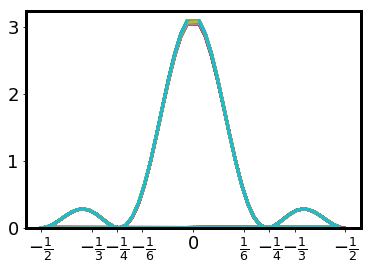

In [175]:
def evaltau(sim,eig,E,plot=False,thetas=np.linspace(-np.pi,np.pi,endpoint=False,num=50)):
    res=sim['res']
    kxmax=res['kx'][-1]
    kymax=res['ky'][-1]
    enb=res['enb'][eig]
    C11=pmdb["material=GaN.stiffness.C11"]
    
    # Find isoenergetic k-points
    def findk(theta):
        kmax=np.sqrt(kxmax**2*np.cos(theta)**2+kymax**2*np.sin(theta)**2)
        Ek=lambda k: enb(k*np.cos(theta),k*np.sin(theta))[0,0]
        if E-Ek(kmax)<=0:
            raise Exception("Energy too high")
            
        k=brentq(lambda k: E-Ek(k),0,kmax)
        k=[k*np.cos(theta),k*np.sin(theta)]
        vk=-(enb(*k,dx=1)*np.cos(theta)+enb(*k,dy=1)*np.sin(theta))[0,0]/hbar
        assert vk>0
        return k,vk
        #dkp=.0001
        #vtheta=(Ekp(kp+dkp)-Ekp(kp-dkp))/dkp /hbar
    ks,vks=[np.array(x) for x in zip(*[findk(t) for t in thetas])]
    
    # Solve at those points
    mbkp=sim['mbkp']
    mbkp.remesh(kmeshmethod=ks)
    with sublog("Solving kp problem"):
        mbkp.solve()
    log("Done solving")
    #plt.plot(theta,sim['mbkp']._mesh.kpen[:,eig,0],'.-')
    #plt.xlim(-np.pi,np.pi)
    
    def evalDA2oW(ik,ikp):
        k= mbkp._kt[ik ]
        kp=mbkp._kt[ikp]
        psi_k = mbkp._mesh.kppsi[ik ,eig]
        psi_kp= mbkp._mesh.kppsi[ikp,eig]
        q=kp-k
        DA=def_spot(q)
        
        ooW=(np.abs(np.sum(psi_kp.conj()*(psi_k),axis=0))**2).integrate(definite=True)
        DA2oW=(np.abs(np.sum(psi_kp.conj()*(DA @ psi_k),axis=0))**2).integrate(definite=True)
        return DA2oW
    
    ivals=np.arange(len(thetas))
    def evaltauk(ik):
        #if ik not in [1,2]: return np.NaN
        #print(mbkp._kt[ik])
        imask=(ivals!=ik)
        kp=mbkp._kt[imask]
        theta,thetap=thetas[ik],thetas[imask]
        DA2oW=np.array([evalDA2oW(ik,ikp) for ikp in ivals[imask]])
        
        alpha=clipangle(thetap-theta)
        dthetap=np.min(np.abs(np.diff(thetap)))
        #print(dthetap)
        #print(vks.shape, DA2oW.shape,alpha.shape,kp.shae)
        kp=np.sqrt(np.sum(kp**2,axis=1))
        #print(vks)
        tauk=1/np.sum(kb*T/(2*np.pi*hbar**2*C11*vks[imask])*DA2oW*(1-np.cos(alpha))   * kp*dthetap)
        if plot:
            plt.plot(alpha,DA2oW)
            plt.ylim(0)
            plt.xticks([-np.pi,-2*np.pi/3,-np.pi/2,-np.pi/3,0,np.pi/3,np.pi/2,2*np.pi/3,np.pi],
                   [r"$-\frac{1}{2}$",r"$-\frac{1}{3}$",r"$-\frac{1}{4}$",r"$-\frac{1}{6}$",
                    "0",
                    r"$\frac{1}{6}$",r"$-\frac{1}{4}$",r"$-\frac{1}{3}$",r"$-\frac{1}{2}$"])
        return tauk
    taus=[evaltauk(ik) for ik in ivals]
    return ks,taus

## Mobility calculation

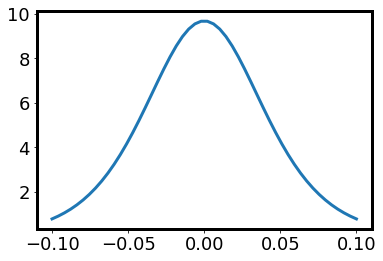

In [176]:
def fp(E):
    return 1/(kb*T)*np.exp(-E/(kb*T))/(1+np.exp(-E/(kb*T)))**2
e=np.linspace(.1,-.1)
plt.plot(e,fp(e))

In [184]:
def evalmu(sim,eig):
    eig=0
    res=sim['res']
    Emin=-.2
    Emax=np.max(res['energy'][:,eig])
    
    theta=np.linspace(-np.pi,np.pi,endpoint=False,num=30)
    dtheta=theta[1]-theta[0]
    k=[[[0,0]]*len(theta)]
    tau=[[0]*len(theta)]
    for E in Emax+-np.linspace(0,np.sqrt(Emax-Emin),20)**2:
        with sublog("Evaluating tau at energy {:.2f}".format(E*1e3)):
            try:
                ki,taui=evaltau(sim,eig,E,thetas=theta)
                k+=[ki];tau+=[taui]
            except Exception as e:
                if str(e) in ["f(a) and f(b) must have different signs","Energy too high"]:
                    log(str(e))
                else: raise
    #print("k",k)
    #print("tau",tau)
    kintgl=0
    for kt,taut in zip(zip(*k),zip(*tau)):
        kt=np.array(kt);taut=np.array(taut);
        ktn=norm(kt,axis=-1)
        #print("kt",kt)
        #print("taut",taut)
        vx=np.array([res['enb'][0](*ki,dx=1)[0,0]/hbar for ki in kt])
        e=np.array([res['enb'][eig](*ki)[0,0] for ki in kt])
        ig=taut*vx**2*fp(e) * ktn
        plt.plot(ktn,ig)
        kintgl+=np.trapz(ig,ktn)*dtheta
    
    pintgl=hbar**2*kintgl
    spin=2
    p0=np.trapz(res['p'],res['x'])
    mu=1/(4*np.pi**2*hbar**2*p0)   * spin *pintgl
    
    return mu

# As-grown

In [185]:
#del sims['asgrown']

In [188]:
runsim('asgrown',strainconds['asgrown'],.54*eV)
savedsim=sims['asgrown']

Already ran


0.997 x 10^13/cm^2


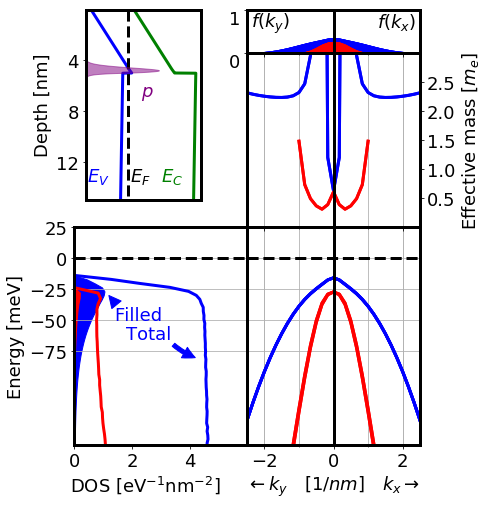

In [189]:
plot_cond(sim)

Assembling k.p matrices ...
Done assembly.
Solving kp problem
Done solving


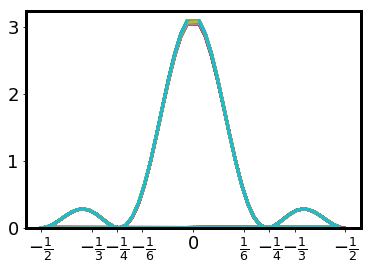

In [190]:
# See what it looks like at some given energy
evaltau(sim,eig=0,E=-.017,plot=True,
    thetas=np.linspace(-np.pi,np.pi,endpoint=False,num=50));

In [ ]:
# Actually calculate the mu
sim['mu']=evalmu(sim,0)
to_unit(sim['mu'],"cm^2/(V.s)")

In [172]:
i_yh=np.argmin(np.sum(np.abs(sim['res']['kt']-np.array([ 0, 1])),axis=-1))
i_yl=np.argmin(np.sum(np.abs(sim['res']['kt']-np.array([ 0,.1])),axis=-1))
i_xh=np.argmin(np.sum(np.abs(sim['res']['kt']-np.array([ 1, 0])),axis=-1))
i_xl=np.argmin(np.sum(np.abs(sim['res']['kt']-np.array([.1, 0])),axis=-1))

In [173]:
np.round(np.trapz(np.abs(sim['res']['kppsi'][i_xl,0,:,:])**2,sim['res']['xkp']),2)

array([ 0.19,  0.31,  0.  ,  0.19,  0.31,  0.  ])

# Junk

In [53]:
sim['mbkp']._mesh._functions['kppsi']=None
sim['mbkp']._mesh._functions['kpen']=None